In [2]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pickle

with open('../data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)

ita_2526 = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2526')
].copy()

dates = pd.to_datetime(ita_2526['date'], dayfirst=True)

print(f"Rows loaded: {len(ita_2526)}")
print(f"Matches played: {len(ita_2526) // 2}")
print(f"Teams: {ita_2526['team'].nunique()}")
print(f"Date range: {dates.min().strftime('%d/%m/%Y')} → {dates.max().strftime('%d/%m/%Y')}")

Rows loaded: 600
Matches played: 300
Teams: 20
Date range: 23/08/2025 → 22/03/2026


# Yellow Cards in Serie A: same question, different data

## Previously on...

In the previous notebook we analysed fouls committed in Serie A 2025/26. We built a statistical toolkit — t-tests, Welch's correction, Mann-Whitney U, and permutation tests — and used it to ask two questions: do away teams foul more than home teams? (no, not significantly) and do some teams foul more than others? (yes, Verona and Milan sit at opposite extremes).

Now we ask the same questions about **yellow cards**. Same league, same teams, same season, same tools. But the data is fundamentally different: a team commits roughly 13 fouls per match but receives only 2-4 yellow cards. Fewer events, more discrete values, a distribution that is further from the familiar bell curve.

This matters. Statistical tools are not one-size-fits-all and they behave differently depending on the data you feed them. This notebook is about seeing that firsthand.

## 1. How are yellow cards distributed?

Same starting point as the fouls analysis: before comparing anything, let's look at the shape of the data.

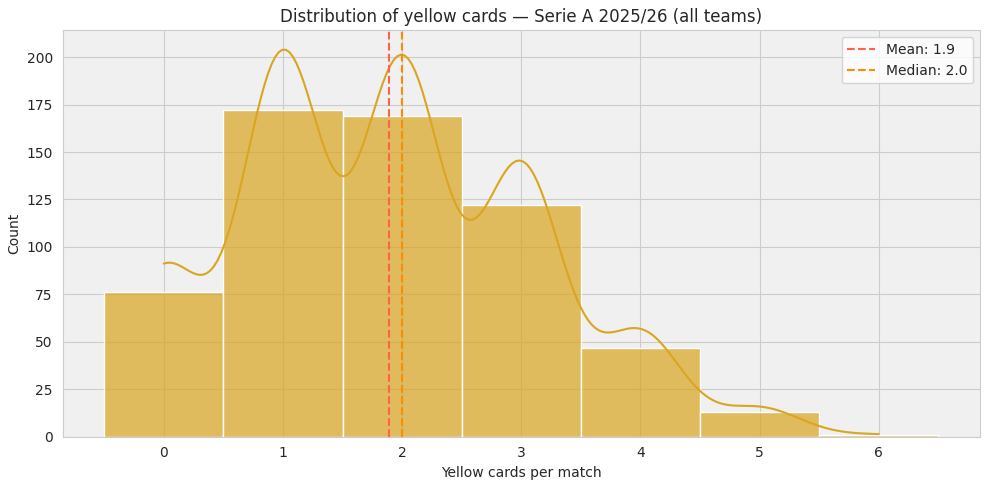

In [5]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')
    
    sns.histplot(ita_2526['yellow_cards'], 
                 bins=range(0, 12), 
                 kde=True,
                 color='goldenrod', 
                 alpha=0.7,
                 discrete=True, 
                 ax=ax)
    
    ax.axvline(ita_2526['yellow_cards'].mean(), color='tomato', 
               linestyle='--', linewidth=1.5, label=f"Mean: {ita_2526['yellow_cards'].mean():.1f}")
    ax.axvline(ita_2526['yellow_cards'].median(), color='darkorange', 
               linestyle='--', linewidth=1.5, label=f"Median: {ita_2526['yellow_cards'].median():.1f}")
    
    ax.set_xlabel('Yellow cards per match')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of yellow cards — Serie A 2025/26 (all teams)')
    ax.legend()
    plt.tight_layout()


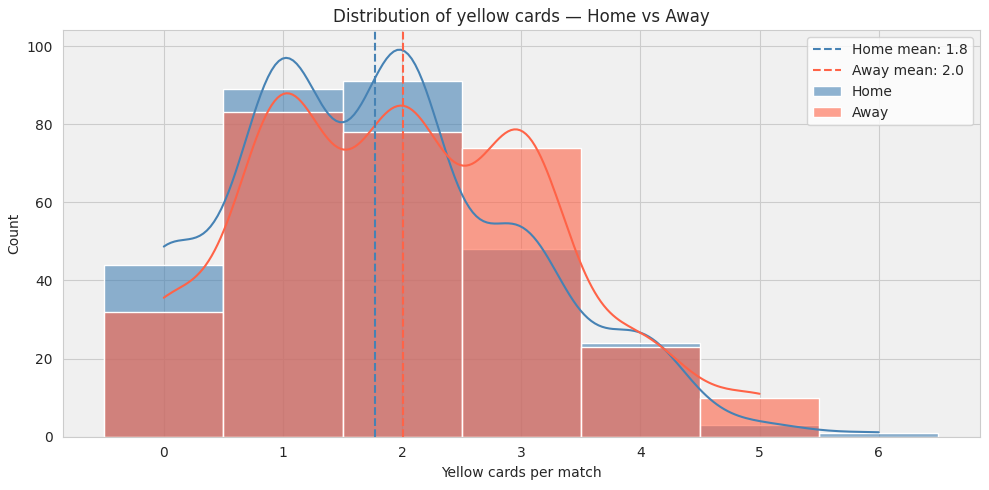

In [7]:
home_yc = ita_2526[ita_2526['venue'] == 'home']['yellow_cards']
away_yc = ita_2526[ita_2526['venue'] == 'away']['yellow_cards']

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')

    sns.histplot(home_yc, bins=range(0, 12), kde=True, discrete=True,
                 color='steelblue', alpha=0.6, label='Home', ax=ax)
    sns.histplot(away_yc, bins=range(0, 12), kde=True, discrete=True,
                 color='tomato', alpha=0.6, label='Away', ax=ax)

    ax.axvline(home_yc.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Home mean: {home_yc.mean():.1f}')
    ax.axvline(away_yc.mean(), color='tomato', linestyle='--', linewidth=1.5,
               label=f'Away mean: {away_yc.mean():.1f}')

    ax.set_xlabel('Yellow cards per match')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of yellow cards — Home vs Away')
    ax.legend()
    plt.tight_layout()


In [8]:
ita_2526.groupby('venue')['yellow_cards'].describe()

,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
away,300.0,2.010000,1.249709,0.0,1.0,2.0,3.0,5.0
home,300.0,1.773333,1.208369,0.0,1.0,2.0,3.0,6.0


### A very different shape

Compare this with the fouls distribution and the difference is immediate. Fouls gave us a smooth, roughly symmetric bell curve centred around 13. Yellow cards give us something much more jagged: values crammed into the 0-6 range, a strong peak at 1, a visible bar at 0, and a right tail that dies off quickly.

This is what happens when events are **rare**. A team gets ~2 yellow cards per match on average. And you cannot get half a yellow card, of course. The data is discrete, sparse, and naturally skewed to the right.

A few observations from the numbers:

- **Mean (1.9) and median (2.0) are still close** — the distribution is not wildly asymmetric, but visually it is far from the smooth bell curve we saw with fouls.
- **The standard deviation (~1.2) is large relative to the mean.** With fouls, the std was about 30% of the mean. Here it is over 60%. Yellow cards are proportionally much noisier.
- **75 matches ended with zero yellow cards for one team** — that is 12.5% of all observations. With fouls, seeing a zero was essentially impossible. This alone tells you the data lives in a different statistical universe.

The home vs. away split shows a familiar pattern: away teams average 2.0 yellow cards vs. 1.8 for home teams. A gap of 0.2 cards per match, small in absolute terms, but proportionally similar to what we saw with fouls. The question is the same: is it real or noise?

But before we test that, notice how the KDE curves look awkward. They are trying to fit a smooth line through data that only takes integer values — the wiggles and dips between integers are artefacts, not real features. This is our first hint that tools designed for continuous data will struggle here.


## 2. Normality check

We already know this will be worse than fouls. But let's see [*how much* worse](https://www.youtube.com/watch?v=p-1zr_wgC1E).

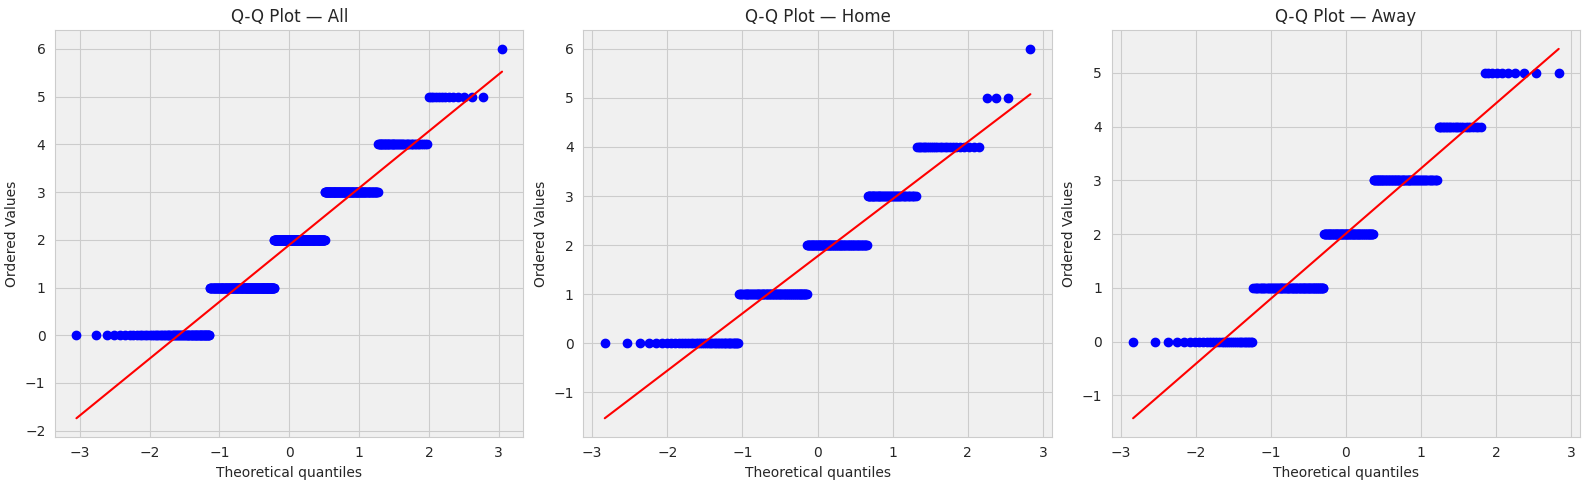

In [9]:
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for ax, (label, data) in zip(axes, [
        ('All', ita_2526['yellow_cards']),
        ('Home', home_yc),
        ('Away', away_yc)
    ]):
        ax.set_facecolor('#f0f0f0')
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f'Q-Q Plot — {label}')
    
    plt.tight_layout()


In [13]:
for label, data in [
    ('All', ita_2526['yellow_cards']),
    ('Home', home_yc),
    ('Away', away_yc)
]:
    stat, p = stats.shapiro(data)
    print(f"{label:6s} -- W={stat:.4f}, p={p:.6f} {' Normal (p>0.05)' if p > 0.05 else ' Not normal (p<0.05)'}")


All    -- W=0.9250, p=0.000000  Not normal (p<0.05)
Home   -- W=0.9181, p=0.000000  Not normal (p<0.05)
Away   -- W=0.9262, p=0.000000  Not normal (p<0.05)


### Reading the results

Compare these Q-Q plots with the fouls ones. With fouls, the points mostly followed the red line with mild deviations at the tails. Here, the points form a **staircase** with flat horizontal bands at 0, 1, 2, 3, 4, 5 with nothing in between. This is what discrete data looks like on a Q-Q plot: the normal distribution expects a smooth continuum of values, but yellow cards can only be integers.

The Shapiro-Wilk W statistics (0.918–0.926) are dramatically lower than what we saw for fouls (0.987–0.989). The p-values are essentially zero and not "small but debatable" like before, but zero to six decimal places. The test is screaming: **this data is not normal.**

And this time we agree with the test. This is not a case of "technically not normal but close enough". The staircase pattern, the discrete values, the skewness, the pile-up at zero — everything says this data lives in a different world from the bell curve.

So what does this mean for our tests?

- **The t-test is on thin ice.** We will run it anyway for comparison, but we should not trust it.
- **Welch's t-test is on the same thin ice.** It fixes the variance problem, not the normality problem.
- **Mann-Whitney and the permutation test do not care.** They make no assumptions about the shape. This is where they earn their keep.

Let's run them all and see what happens.


## 3. Home vs. Away: do away teams get more yellow cards?

In [14]:
# Levene's test
lev_stat, lev_p = stats.levene(home_yc, away_yc)

# Student's t-test
t_stat_s, t_p_s = stats.ttest_ind(home_yc, away_yc, equal_var=True)

# Welch's t-test
t_stat_w, t_p_w = stats.ttest_ind(home_yc, away_yc, equal_var=False)

# Mann-Whitney U
u_stat, u_p = stats.mannwhitneyu(home_yc, away_yc, alternative='two-sided')
n1, n2 = len(home_yc), len(away_yc)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

# Permutation test
np.random.seed(42)
observed_diff = away_yc.mean() - home_yc.mean()
pooled = np.concatenate([home_yc.values, away_yc.values])
n_home = len(home_yc)
n_permutations = 10_000
perm_diffs = np.zeros(n_permutations)
for i in range(n_permutations):
    np.random.shuffle(pooled)
    perm_diffs[i] = pooled[n_home:].mean() - pooled[:n_home].mean()
p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"Observed difference (away - home): {observed_diff:.4f}")
print(f"Levene's test:       F={lev_stat:.4f}, p={lev_p:.4f} — {'Equal variance' if lev_p > 0.05 else 'Unequal variance'}")
print(f"Student's t-test:    t={t_stat_s:.4f}, p={t_p_s:.4f}")
print(f"Welch's t-test:      t={t_stat_w:.4f}, p={t_p_w:.4f}")
print(f"Mann-Whitney U:      U={u_stat:.1f}, p={u_p:.4f}")
print(f"Permutation test:    p={p_perm:.4f}")
print(f"Rank-biserial:       {rank_biserial:.4f}")


Observed difference (away - home): 0.2367
Levene's test:       F=0.3423, p=0.5587 — Equal variance
Student's t-test:    t=-2.3581, p=0.0187
Welch's t-test:      t=-2.3581, p=0.0187
Mann-Whitney U:      U=40168.5, p=0.0191
Permutation test:    p=0.0215
Rank-biserial:       0.1074


### A surprise

Remember the fouls analysis? Four tests, all non-significant, p-values around 0.19. Here, with yellow cards:

| Test | p-value | Significant? |
|------|---------|:--:|
| Student's t-test | 0.019 | Yes |
| Welch's t-test | 0.019 | Yes |
| Mann-Whitney U | 0.019 | Yes |
| Permutation test | 0.022 | Yes |

All four tests agree: away teams receive **significantly more yellow cards** than home teams. The difference is 0.24 cards per match. Small in absolute terms, but statistically distinguishable from noise.

A few things to notice:

**The tests all agree despite the data being clearly non-normal.** This is a useful lesson: non-normality does not automatically invalidate the t-test. With 300 observations per group, the Central Limit Theorem still provides some protection meaning the *sampling distribution of the mean* is approximately normal even if the underlying data is not. The t-test is more robust than its assumptions suggest, especially with large samples.

**Levene's test says equal variance (p=0.56).** Unlike fouls, the spread of yellow cards is similar for home and away teams (std ≈ 1.2 for both). This is why Student's and Welch's give identical results: there is nothing to correct.

**The effect size is small but real.** The rank-biserial (0.107) is about twice what we saw for fouls (0.049). Still modest, i.e. if you pick a random home match and a random away match, the away team got more yellow cards about 55% of the time. But unlike fouls, the signal is strong enough to rise above the noise.

**Why might yellow cards show a home/away effect that fouls do not?** One possible explanation: yellow cards involve **referee judgement**. Fouls are relatively objective events, a contact happened or it didn't. But the decision to show a yellow card has a discretionary element. Research in sports psychology has repeatedly shown that referees are influenced by home crowds, often unconsciously. The home advantage in yellow cards may not be about how teams play, it may be about how referees decide.


## 4. Does any team stand out? One team vs. the rest

Same approach as fouls: for each team, compare their yellow cards per match against the rest of the league.

In [15]:
team_yc_stats = (
    ita_2526
    .groupby('team')['yellow_cards']
    .agg(['sum', 'mean', 'std', 'count'])
    .round(2)
    .sort_values('mean', ascending=False)
)

team_yc_stats = team_yc_stats.rename(columns={'sum': 'total'})
league_mean_yc = ita_2526['yellow_cards'].mean()
team_yc_stats['diff_from_league'] = (team_yc_stats['mean'] - league_mean_yc).round(2)

print(f"League average: {league_mean_yc:.2f} yellow cards per match\n")
team_yc_stats


League average: 1.89 yellow cards per match



,total,mean,std,count,diff_from_league
team,,,,,
Cagliari,73.0,2.43,1.55,30,0.54
Verona,68.0,2.27,1.26,30,0.38
Fiorentina,67.0,2.23,1.22,30,0.34
Sassuolo,67.0,2.23,1.22,30,0.34
Como,62.0,2.07,1.23,30,0.18
Cremonese,62.0,2.07,1.08,30,0.18
Lazio,60.0,2.00,1.44,30,0.11
Pisa,60.0,2.00,1.20,30,0.11
Torino,59.0,1.97,1.19,30,0.08


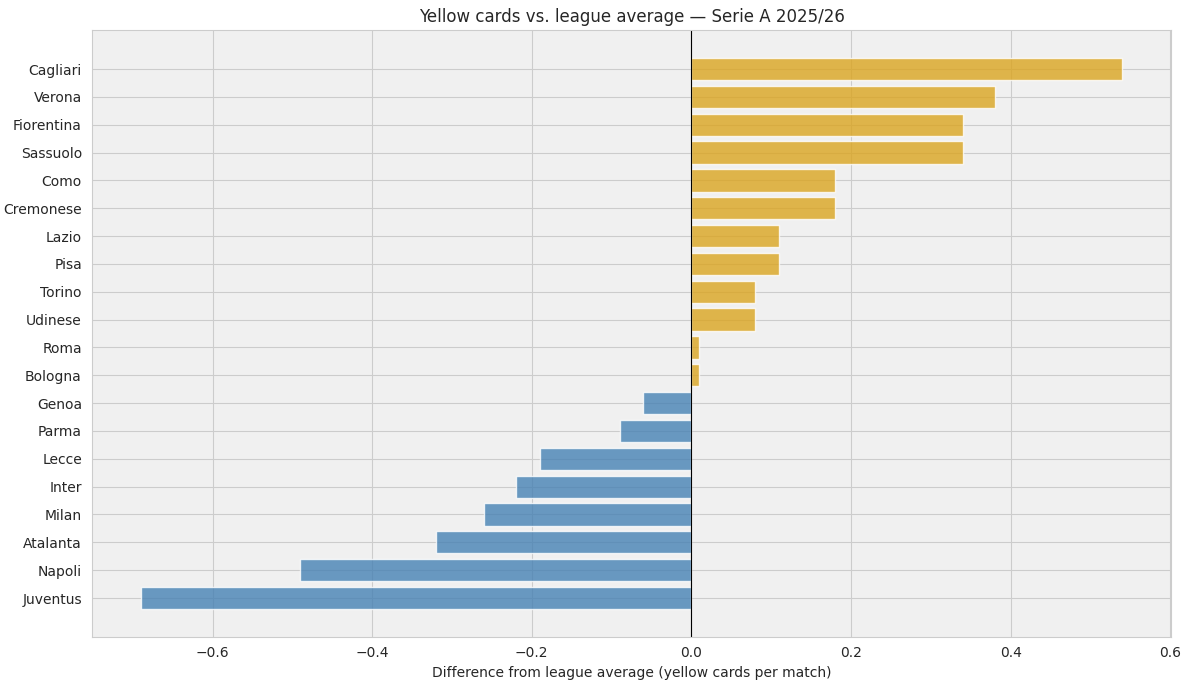

In [16]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.set_facecolor('#f0f0f0')

    colors = ['goldenrod' if x > 0 else 'steelblue' for x in team_yc_stats['diff_from_league']]
    
    ax.barh(team_yc_stats.index, team_yc_stats['diff_from_league'], color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Difference from league average (yellow cards per match)')
    ax.set_title('Yellow cards vs. league average — Serie A 2025/26')
    ax.invert_yaxis()
    plt.tight_layout()


In [17]:
np.random.seed(42)

results_yc = []
for team_name in team_yc_stats.index:
    team = ita_2526[ita_2526['team'] == team_name]['yellow_cards']
    rest = ita_2526[ita_2526['team'] != team_name]['yellow_cards']
    
    _, t_p = stats.ttest_ind(team, rest, equal_var=False)
    _, u_p = stats.mannwhitneyu(team, rest, alternative='two-sided')
    
    observed_diff = team.mean() - rest.mean()
    pooled = np.concatenate([team.values, rest.values])
    n_team = len(team)
    perm_diffs = np.zeros(10_000)
    for i in range(10_000):
        np.random.shuffle(pooled)
        perm_diffs[i] = pooled[:n_team].mean() - pooled[n_team:].mean()
    p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
    
    pooled_std = np.sqrt((team.std()**2 + rest.std()**2) / 2)
    cohens_d = observed_diff / pooled_std if pooled_std > 0 else 0
    
    results_yc.append({
        'team': team_name,
        'mean': team.mean(),
        'diff': observed_diff,
        'welch_p': t_p,
        'mannwhitney_p': u_p,
        'perm_p': p_perm,
        'cohens_d': cohens_d
    })

results_yc_df = pd.DataFrame(results_yc).sort_values('mean', ascending=False).round(4)
results_yc_df


,team,mean,diff,welch_p,mannwhitney_p,perm_p,cohens_d
0,Cagliari,2.4333,0.5702,0.0558,0.0265,0.0159,0.4106
1,Verona,2.2667,0.3947,0.1032,0.0737,0.0988,0.3173
2,Fiorentina,2.2333,0.3596,0.1263,0.0902,0.1238,0.2929
3,Sassuolo,2.2333,0.3596,0.1263,0.1131,0.1296,0.2929
4,Como,2.0667,0.1842,0.4299,0.3068,0.4535,0.1495
5,Cremonese,2.0667,0.1842,0.3731,0.3776,0.4541,0.1583
6,Lazio,2.0000,0.1140,0.6729,0.7989,0.6493,0.0854
7,Pisa,2.0000,0.1140,0.6169,0.5629,0.6520,0.0935
8,Torino,1.9667,0.0789,0.7257,0.6716,0.7643,0.0651
9,Udinese,1.9667,0.0789,0.7518,0.8635,0.7599,0.0617


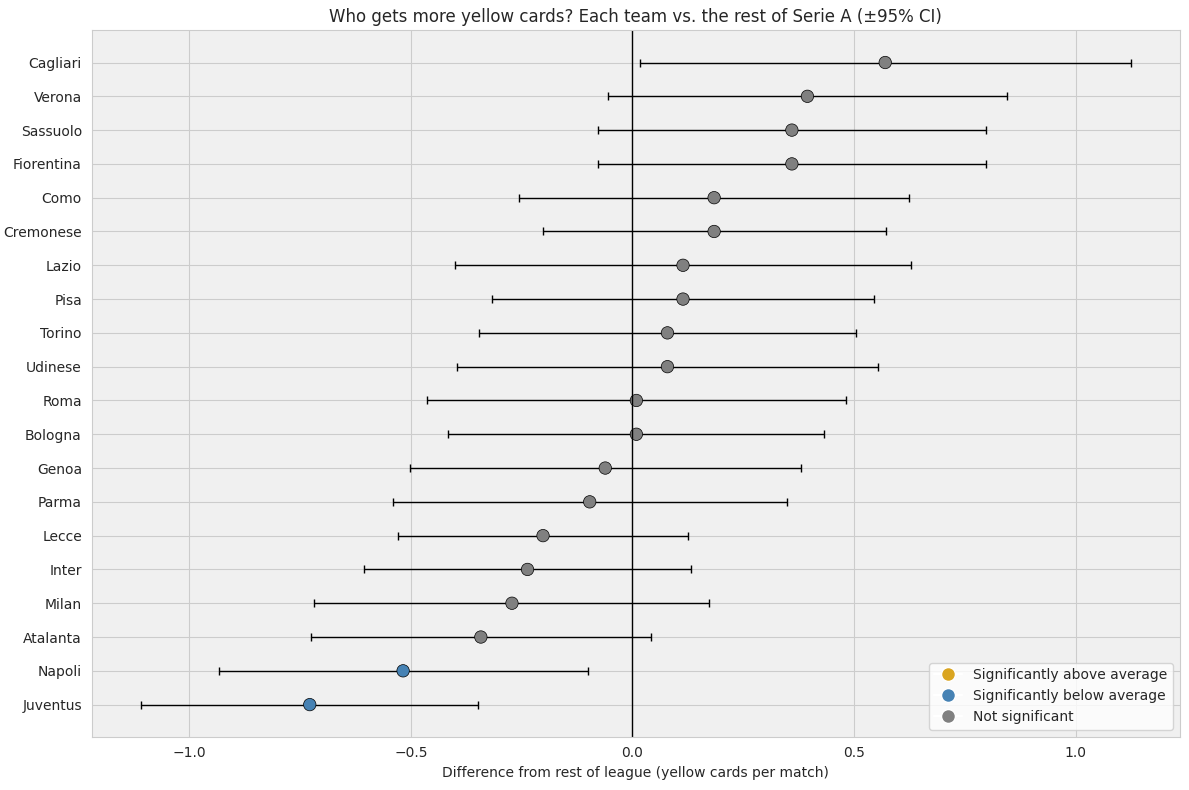

In [18]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_facecolor('#f0f0f0')

    plot_df = results_yc_df.sort_values('diff', ascending=True).copy()
    
    ci_data = []
    for _, row in plot_df.iterrows():
        team_data = ita_2526[ita_2526['team'] == row['team']]['yellow_cards']
        se = team_data.std() / np.sqrt(len(team_data))
        ci_data.append(se * 1.96)
    
    plot_df['ci'] = ci_data
    
    colors = ['goldenrod' if p < 0.05 and d > 0 
              else 'steelblue' if p < 0.05 and d < 0 
              else 'grey' 
              for p, d in zip(plot_df['welch_p'], plot_df['diff'])]
    
    y_pos = range(len(plot_df))
    
    ax.errorbar(plot_df['diff'], y_pos, xerr=plot_df['ci'], 
                fmt='none', ecolor='black', elinewidth=1, capsize=3, zorder=1)
    ax.scatter(plot_df['diff'], y_pos, c=colors, s=80, zorder=2, edgecolors='black', linewidth=0.5)
    
    ax.axvline(0, color='black', linewidth=1, linestyle='-')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(plot_df['team'])
    ax.set_xlabel('Difference from rest of league (yellow cards per match)')
    ax.set_title('Who gets more yellow cards? Each team vs. the rest of Serie A (±95% CI)')
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='goldenrod', markersize=10, label='Significantly above average'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Significantly below average'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=10, label='Not significant')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()


### Reading the results

The first thing that jumps out: **far fewer teams are significantly different from the league average.** With fouls, we had 7 teams clearly separated from the pack. With yellow cards, only 2-3 teams stand out, and even those are less emphatic.

**Significantly below average** (all tests p < 0.05):
- **Juventus** (d=-0.63) — by far the cleanest team in terms of yellow cards. 1.2 per match, nearly 0.7 fewer than the league average. This is the strongest signal in the entire table.
- **Napoli** (d=-0.43) — 1.4 per match, about 0.5 below average. All three tests agree.

**The grey zone:**
- **Cagliari** — the tests **disagree**. Welch's says not significant (p=0.056), but Mann-Whitney (p=0.027) and the permutation test (p=0.016) say yes. This is exactly the kind of divergence we warned about: with discrete, non-normal data, the t-test and rank-based tests can reach different conclusions. When they disagree, the non-parametric tests are more trustworthy here.
- **Verona, Fiorentina, Sassuolo** — all hovering around p=0.07-0.13. Hints of something, but not convincing.

**Everyone else:** indistinguishable from the league average.


### Why so few significant teams?


With fouls, we could detect differences of ~2 fouls per match against a mean of 13 (a ~15% deviation). Here, the largest deviation is Juventus at 0.7 yellow cards against a mean of 1.9 (a ~37% deviation). In percentage terms, Juventus's deviation is actually *larger* than Verona's was for fouls and yet fewer teams reach significance overall.

The reason is **noise relative to signal**. Yellow cards have a standard deviation of ~1.2 on a mean of ~1.9. That is a coefficient of variation of 63%. Fouls had a coefficient of variation of ~32%. The data is proportionally *twice as noisy*, which makes it much harder for statistical tests to distinguish real patterns from randomness.

This is a fundamental lesson: **rarer events are harder to analyse**. Not because the tools are worse, but because each observation carries less information. You need either more data or a larger effect to reach the same level of confidence.

### A comparison worth making


Let's put the fouls and yellow cards rankings side by side for the most interesting teams:

| Team | Fouls rank | Yellow cards rank | Pattern |
|------|:--:|:--:|---------|
| Verona | 1st (most) | 2nd (most) | Consistently aggressive |
| Cagliari | 2nd | 1st | Consistently aggressive |
| Milan | 20th (least) | 17th | Clean across the board |
| Lazio | 19th | 7th | Few fouls, average cards — interesting |
| Juventus | 14th | 20th (least) | Average fouls, very few cards |
| Roma | 3rd | 11th | Many fouls, average cards — interesting |

Some teams are consistently aggressive or clean across both metrics. But look at the outliers: **Roma** commits the 3rd most fouls but gets an average number of yellow cards. **Juventus** commits an average number of fouls but gets the fewest yellow cards in the league. **Lazio** commits very few fouls but gets an average number of cards.

These discrepancies are exactly what notebook 03 will investigate: the *rate* of yellow cards per foul. A team that fouls a lot but gets few cards, or fouls little but gets many: those are the cases that raise eyebrows. And, as it happens, that is exactly the claim that started this whole investigation.


## 5. Wrapping up: what did we learn?

### About Serie A 2025/26

- **Away teams get significantly more yellow cards than home teams** — 2.0 vs. 1.8 per match. Unlike fouls, where the home/away difference was noise, here it is statistically significant across all four tests. Referee judgement, influenced by crowd pressure, is a plausible explanation.
- **Very few teams stand out individually.** Only Juventus and Napoli receive significantly fewer yellow cards than average. At the top, Cagliari is borderline — the tests disagree, which is itself informative.
- **The rankings don't match the fouls rankings.** Roma fouls a lot but gets average cards. Juventus fouls an average amount but gets the fewest cards. These discrepancies point directly to the rate analysis in the next notebook.


### About the tools

- **Same tools, different behaviour.** The t-test, which was "good enough" for fouls, is on shakier ground with yellow cards. The data is more discrete, more skewed, and further from normal — and we saw the tests start to disagree (Cagliari).
- **Rarer events are harder to analyse.** Yellow cards are proportionally twice as noisy as fouls. This means fewer teams reach statistical significance, even when their deviations are large in percentage terms.
- **When tests disagree, trust the non-parametric ones.** Mann-Whitney and the permutation test make no assumptions about the shape of the data. With discrete, skewed distributions like yellow cards, they are the safer choice.
- **The nature of the data determines the tool, not the other way around.** This is perhaps the single most important takeaway across both notebooks.


## Bonus: head-to-head comparison

Same function as the fouls notebook, adapted for yellow cards. Let's test the extremes and a close pair.


In [19]:
def compare_two_teams_yc(df, team_a, team_b, n_permutations=10_000):
    """Compare yellow cards between two teams."""
    a = df[df['team'] == team_a]['yellow_cards']
    b = df[df['team'] == team_b]['yellow_cards']
    
    diff = a.mean() - b.mean()
    
    # Welch's t-test
    _, welch_p = stats.ttest_ind(a, b, equal_var=False)
    
    # Mann-Whitney U
    u_stat, mw_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    n1, n2 = len(a), len(b)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    
    # Permutation test
    pooled = np.concatenate([a.values, b.values])
    n_a = len(a)
    perm_diffs = np.zeros(n_permutations)
    for i in range(n_permutations):
        np.random.shuffle(pooled)
        perm_diffs[i] = pooled[:n_a].mean() - pooled[n_a:].mean()
    perm_p = np.mean(np.abs(perm_diffs) >= np.abs(diff))
    
    # Cohen's d
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    cohens_d = diff / pooled_std if pooled_std > 0 else 0
    
    print(f"{'='*50}")
    print(f"  {team_a} vs {team_b}")
    print(f"{'='*50}")
    print(f"  {team_a:15s}  mean={a.mean():.2f}  std={a.std():.2f}  n={len(a)}")
    print(f"  {team_b:15s}  mean={b.mean():.2f}  std={b.std():.2f}  n={len(b)}")
    print(f"  Difference:    {diff:+.2f} yellow cards/match")
    print(f"{'─'*50}")
    print(f"  Welch's t-test:    p={welch_p:.4f}")
    print(f"  Mann-Whitney U:    p={mw_p:.4f}")
    print(f"  Permutation test:  p={perm_p:.4f}")
    print(f"  Cohen's d:         {cohens_d:.3f}")
    print(f"  Rank-biserial:     {rank_biserial:.3f}")
    print(f"{'='*50}")
    
    return {
        'team_a': team_a, 'team_b': team_b,
        'mean_a': a.mean(), 'mean_b': b.mean(), 'diff': diff,
        'welch_p': welch_p, 'mannwhitney_p': mw_p, 'perm_p': perm_p,
        'cohens_d': cohens_d, 'rank_biserial': rank_biserial
    }


In [20]:
np.random.seed(42)
_ = compare_two_teams_yc(ita_2526, 'Cagliari', 'Juventus')
print()
_ = compare_two_teams_yc(ita_2526, 'Roma', 'Juventus')
print()
_ = compare_two_teams_yc(ita_2526, 'Verona', 'Cagliari')


  Cagliari vs Juventus
  Cagliari         mean=2.43  std=1.55  n=30
  Juventus         mean=1.20  std=1.06  n=30
  Difference:    +1.23 yellow cards/match
──────────────────────────────────────────────────
  Welch's t-test:    p=0.0007
  Mann-Whitney U:    p=0.0016
  Permutation test:  p=0.0010
  Cohen's d:         0.929
  Rank-biserial:     -0.466

  Roma vs Juventus
  Roma             mean=1.90  std=1.32  n=30
  Juventus         mean=1.20  std=1.06  n=30
  Difference:    +0.70 yellow cards/match
──────────────────────────────────────────────────
  Welch's t-test:    p=0.0278
  Mann-Whitney U:    p=0.0319
  Permutation test:  p=0.0359
  Cohen's d:         0.583
  Rank-biserial:     -0.312

  Verona vs Cagliari
  Verona           mean=2.27  std=1.26  n=30
  Cagliari         mean=2.43  std=1.55  n=30
  Difference:    -0.17 yellow cards/match
──────────────────────────────────────────────────
  Welch's t-test:    p=0.6488
  Mann-Whitney U:    p=0.5804
  Permutation test:  p=0.7150
  Cohe

Three pairs, three stories:

- **Cagliari vs. Juventus** (d=0.93, p<0.001): over one yellow card per match apart. A large effect, clear significance. These two teams live in different disciplinary universes.
- **Roma vs. Juventus** (d=0.58, p=0.028): Roma gets an average number of yellow cards, Juventus gets the fewest — and even this moderate difference is significant. Keep this pair in mind for the next notebook: Roma commits the 3rd most fouls in the league but gets average cards. Juventus commits an average number of fouls but gets the fewest cards. The rate will tell a very different story.
- **Verona vs. Cagliari** (d=-0.12, p=0.65): the two most aggressive teams are indistinguishable from each other. 0.17 cards per match apart — pure noise. Being at the top of the table does not mean you can tell teams apart within that group.

Notice how Roma vs. Juventus is significant despite Roma being average in the league table. This is the power of head-to-head comparison: a team that looks unremarkable against the full league can still be significantly different from a specific opponent. Context matters.

> **Next up:** notebook 03, where we bring fouls and yellow cards together and investigate the rate that started this whole investigation.


---

# Appendix

## Bibliography


1. Nevill, A.M., Balmer, N.J. & Williams, A.M. (2002). "The influence of crowd noise and experience upon refereeing decisions in football." *Psychology of Sport and Exercise*, 3(4), 261–272.

2. Boyko, R.H., Boyko, A.R. & Boyko, M.G. (2007). "Referee bias contributes to home advantage in English Premiership football." *Journal of Sports Sciences*, 25(11), 1185–1194.

3. Scoppa, V. (2008). "Are subjective evaluations influenced by reference group outcomes? Evidence from Serie A." *Journal of Sports Economics*, 9(4), 401–419.

4. Dohmen, T. & Sauermann, J. (2016). "Referee bias." *Journal of Economic Surveys*, 30(4), 679–695.

5. Dilger, A. & Vischer, L. (2020). "Home-bias in referee decisions: Evidence from 'Ghost Matches' during the Covid-19 pandemic." *Economics Letters*, 197, 109621.
